##### Copyright 2026 Google LLC.

Greedy Best-First Search

Step | Node | h(n) | Path
----------------------------------------
1    | S    | 7    | S
2    | B    | 2    | S -> B
3    | D    | 0    | S -> B -> D

Goal Found!
Path : S -> B -> D
Cost : 9


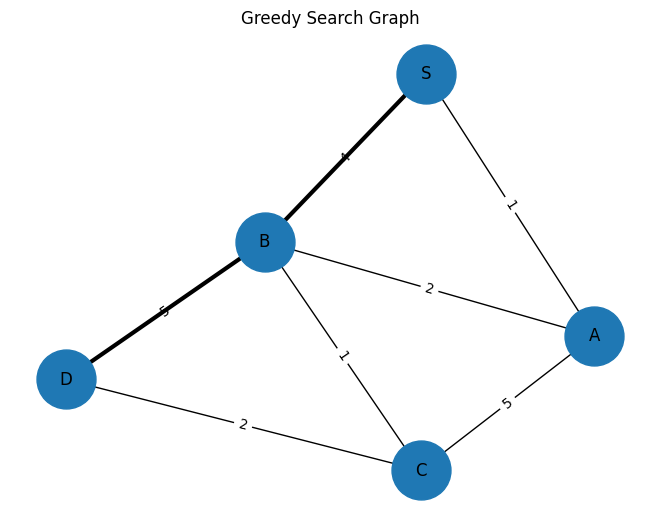


NOTE: Greedy uses only heuristic, so result may not be optimal.


In [6]:
# ============================================================
# AI Assignment 3: Greedy Best-First Search (Modified Version)
# ============================================================

import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Graph (changed node names)
graph_map = {
    'S': [('A', 1), ('B', 4)],
    'A': [('S', 1), ('B', 2), ('C', 5)],
    'B': [('S', 4), ('A', 2), ('C', 1), ('D', 5)],
    'C': [('A', 5), ('B', 1), ('D', 2)],
    'D': [('B', 5), ('C', 2)]
}

# Heuristic values
h_map = {
    'S': 7,
    'A': 6,
    'B': 2,
    'C': 1,
    'D': 0
}

# ---------------- GREEDY FUNCTION ----------------
def greedy_best_first(g, h, start_node, goal_node):
    pq = [(h[start_node], start_node, [start_node])]
    visited_nodes = set()

    print("\nStep | Node | h(n) | Path")
    print("-" * 40)

    step_count = 1

    while pq:
        h_val, current_node, path = heapq.heappop(pq)

        if current_node in visited_nodes:
            continue

        print(f"{step_count:<4} | {current_node:<4} | {h_val:<4} | {' -> '.join(path)}")
        step_count += 1

        if current_node == goal_node:
            # calculate real cost
            total_cost = 0
            for i in range(len(path) - 1):
                for nb, wt in g[path[i]]:
                    if nb == path[i+1]:
                        total_cost += wt

            print("\nGoal Found!")
            print("Path :", ' -> '.join(path))
            print("Cost :", total_cost)
            return path

        visited_nodes.add(current_node)

        for next_node, _ in g[current_node]:
            if next_node not in visited_nodes:
                heapq.heappush(pq, (h[next_node], next_node, path + [next_node]))

    return None

# ---------------- GRAPH DRAW ----------------
def show_graph(g, path=None):
    G = nx.Graph()

    for node in g:
        for neighbour, weight in g[node]:
            G.add_edge(node, neighbour, weight=weight)

    pos = nx.spring_layout(G)

    nx.draw(G, pos, with_labels=True, node_size=1800)

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    if path:
        edge_list = list(zip(path, path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=edge_list, width=3)

    plt.title("Greedy Search Graph")
    plt.show()

# ---------------- MAIN ----------------
if __name__ == "__main__":
    print("Greedy Best-First Search")

    result_path = greedy_best_first(graph_map, h_map, start_node='S', goal_node='D')

    if result_path:
        show_graph(graph_map, result_path)

    print("\nNOTE: Greedy uses only heuristic, so result may not be optimal.")